In [32]:
#Librerías 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
!pip install wordcloud

In [3]:
#Datasets
ruta1 = "DATASET_DRL_LIMPIO1.csv"
df1 = pd.read_csv(ruta1)
ruta2 = "DATASET_DRL_LIMPIO2.csv"
df2 = pd.read_csv(ruta2)
# Consolidadar DF

# 1. Concatenar los DataFrames verticalmente
# ignore_index=True evita que los índices se repitan (0, 1, 2... de cada DF)
df_total = pd.concat([df1, df2], ignore_index=True)

# 2. Recomendación técnica: Eliminar duplicados globales
# Es posible que una noticia esté en ambos archivos. 
# Usamos 'Titulo_norm' para asegurar unicidad.
n_antes = len(df_total)
df_total = df_total.drop_duplicates(subset=['Titulo_norm'], keep='first')
n_despues = len(df_total)

# 3. Guardar el corpus final unificado
df_total.to_csv('DATASET_DRL_CONSOLIDADO.csv', index=False)

# Métricas de la unión
print(f"Registros tras la unión: {n_antes}")
print(f"Registros tras eliminación de duplicados cruzados: {n_despues}")
print(f"Duplicados eliminados en la fusión: {n_antes - n_despues}")
print("Archivo 'DATASET_DRL_CONSOLIDADO.csv' generado con éxito.")

Registros tras la unión: 5675
Registros tras eliminación de duplicados cruzados: 5674
Duplicados eliminados en la fusión: 1
Archivo 'DATASET_DRL_CONSOLIDADO.csv' generado con éxito.


In [9]:
RUTA = "ETIQUETADO.csv"
df = pd.read_csv(RUTA)
# Convertir Fecha a datetime (formato ISO o el detectado)
df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')

# Convertir Tipo_noticia y Fuente a categorías (optimiza memoria y facilita el plot)
df['Tipo_noticia'] = df['Tipo_noticia'].astype('category')
df['Fuente'] = df['Fuente'].astype('category')

In [12]:
# 1. Función para limpiar el rastro de la fuente en el título
def limpiar_fuente_en_titulo(texto):
    if pd.isna(texto): return texto
    # Dividimos por el último guion encontrado
    partes = str(texto).rsplit(' - ', 1)
    return partes[0].strip()

# Aplicar la limpieza al título original
df['Titulo'] = df['Titulo'].apply(limpiar_fuente_en_titulo)

# 2. Re-normalizar el título (ahora sin la fuente)
# Usamos la lógica de normalización que definimos antes
import re
import unicodedata

def normalize_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Titulo_norm'] = df['Titulo'].apply(normalize_text)


In [15]:
# 3. Casteo de tipos de datos
# Convertir Fecha a datetime
df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')

# Convertir columnas categóricas para ahorrar memoria y mejorar el rendimiento de gráficos
df['Tipo_noticia'] = df['Tipo_noticia'].astype('category')
df['Fuente'] = df['Fuente'].astype('category')

# 4. Ingeniería de características (Feature Engineering) para el EDA
# Extraer dimensiones temporales
df['Año'] = df['Fecha'].dt.year
df['Mes'] = df['Fecha'].dt.month
df['Dia_Semana'] = df['Fecha'].dt.day_name()

# Métricas de texto (Ayudan a identificar anomalías o importancia)
df['Longitud_Titular'] = df['Titulo'].str.len()
df['Conteo_Palabras'] = df['Titulo'].str.split().str.len()

# 5. Verificación de salud de los datos
print("--- Reporte de Calidad de Datos ---")
print(df.info())
print("\nValores nulos detectados:")
print(df.isnull().sum())

--- Reporte de Calidad de Datos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5674 entries, 0 to 5673
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Query             5674 non-null   object        
 1   Titulo            5674 non-null   object        
 2   Fuente            5674 non-null   category      
 3   Fecha             5674 non-null   datetime64[ns]
 4   url               5674 non-null   object        
 5   Hora              5674 non-null   object        
 6   Año               5674 non-null   int32         
 7   Mes               5674 non-null   int32         
 8   Dia               5674 non-null   object        
 9   Titulo_norm       5674 non-null   object        
 10  Dia_semana        1776 non-null   object        
 11  Tipo_noticia      5674 non-null   category      
 12  Dia_Semana        5674 non-null   object        
 13  Longitud_Titular  5674 non-null   int64   

In [21]:
# 1. Eliminar columnas por nombre para mayor seguridad (o por posición si prefieres)
# Columnas a eliminar: Dia_semana (pos 10), Dia (pos 8), url (pos 4)
cols_to_drop = ['Dia_semana', 'Dia', 'url']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 2. Eliminación de duplicados definitiva
# Usamos 'Titulo_norm' porque es la versión limpia del texto
n_antes = len(df)
df = df.drop_duplicates(subset=['Titulo_norm'], keep='first')
n_despues = len(df)

# 3. Resetear el índice para que sea continuo
df = df.reset_index(drop=True)

print(f"--- Limpieza Completada ---")
print(f"Registros originales: {n_antes}")
print(f"Registros tras eliminar duplicados: {n_despues}")
print(f"Duplicados eliminados: {n_antes - n_despues}")
print(f"Columnas actuales: {df.columns.tolist()}")


--- Limpieza Completada ---
Registros originales: 5290
Registros tras eliminar duplicados: 5290
Duplicados eliminados: 0
Columnas actuales: ['Query', 'Titulo', 'Fuente', 'Fecha', 'Hora', 'Año', 'Mes', 'Titulo_norm', 'Tipo_noticia', 'Dia_Semana', 'Longitud_Titular', 'Conteo_Palabras']


Query                       object
Titulo                      object
Fuente                    category
Fecha               datetime64[ns]
Hora                        object
Año                          int32
Mes                          int32
Titulo_norm                 object
Tipo_noticia              category
Dia_Semana                  object
Longitud_Titular             int64
Conteo_Palabras              int64
dtype: object

C:\Users\Jhon Fernando Tascón\AppData\Local\Temp\ipykernel_14860\471627886.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


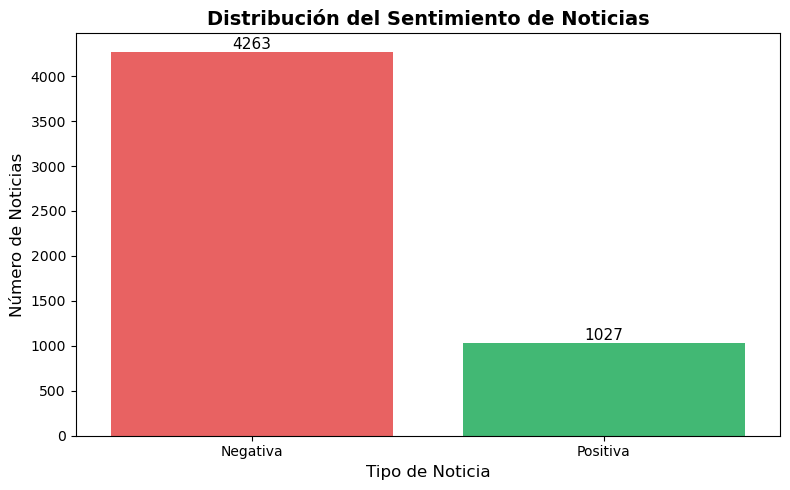

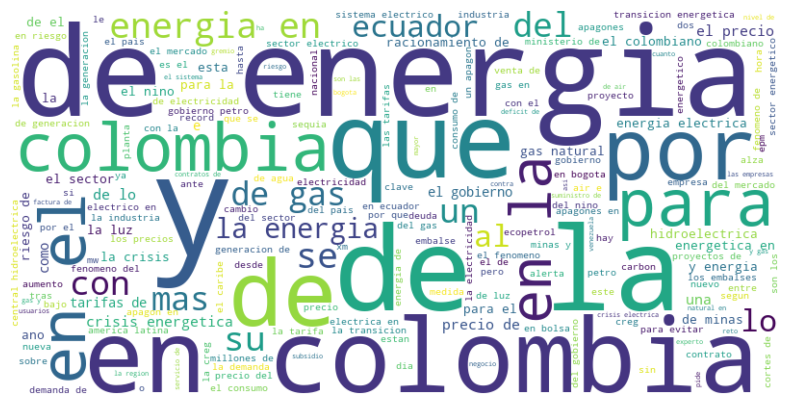

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud  # <-- La 'W' y 'C' mayúsculas son la clase, no el módulo

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x='Tipo_noticia',
    palette={'Negativa': '#ff4b4b', 'Positiva': '#2ecc71'}
)

# Títulos
plt.title('Distribución del Sentimiento de Noticias',
          fontsize=14, fontweight='bold')

# Etiquetas
plt.xlabel('Tipo de Noticia', fontsize=12)
plt.ylabel('Número de Noticias', fontsize=12)

# Agregar valores encima de cada barra
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.tight_layout()
plt.show()

# 2. WordCloud (Si aquí fue el error)
textos_negativos = " ".join(df[df['Tipo_noticia'] == 'Negativa']['Titulo_norm'])

# CORRECTO: WordCloud() es la clase dentro del módulo wordcloud
wc = WordCloud(width=800, height=400, background_color='white').generate(textos_negativos)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

C:\Users\Jhon Fernando Tascón\AppData\Local\Temp\ipykernel_14860\3634668905.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sent_time = df.groupby(['Fecha','Tipo_noticia']).size().unstack(fill_value=0)


<Axes: xlabel='Fecha'>

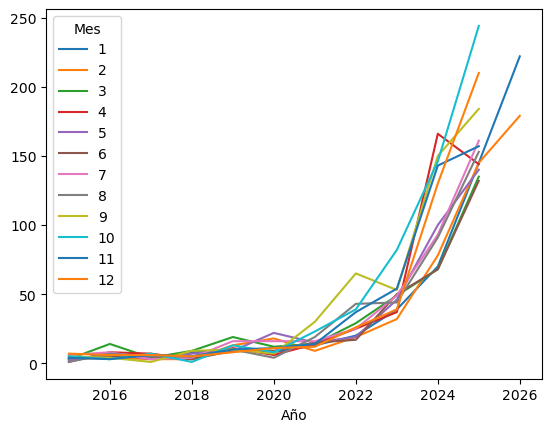

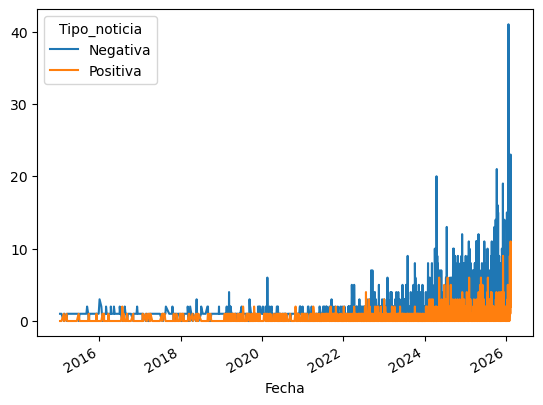

In [35]:
df.groupby(['Año','Mes']).size().unstack().plot()
sent_time = df.groupby(['Fecha','Tipo_noticia']).size().unstack(fill_value=0)
sent_time.plot()


C:\Users\Jhon Fernando Tascón\AppData\Local\Temp\ipykernel_14860\3845296985.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['YearMonth','Tipo_noticia'])


<Figure size 640x480 with 0 Axes>

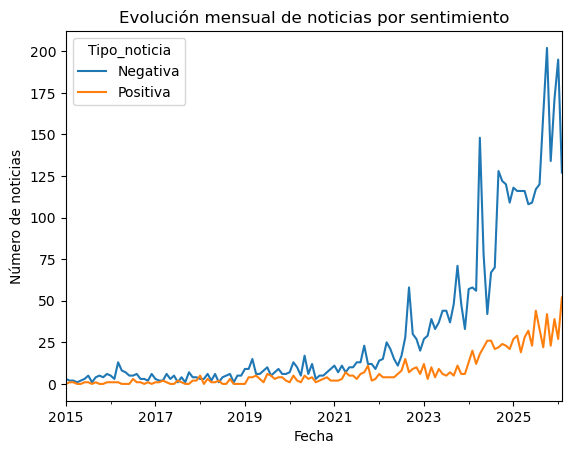

In [38]:
#Agrupación por mes
df['Fecha'] = pd.to_datetime(df['Fecha'])
df = df.sort_values('Fecha')

df['YearMonth'] = df['Fecha'].dt.to_period('M')

# Conteo Mensual por noticias
sent_month = (
    df.groupby(['YearMonth','Tipo_noticia'])
      .size()
      .unstack(fill_value=0)
)

sent_month.index = sent_month.index.to_timestamp()
#Gráfico
plt.figure()
sent_month.plot()
plt.title('Evolución mensual de noticias por sentimiento')
plt.xlabel('Fecha')
plt.ylabel('Número de noticias')
plt.show()


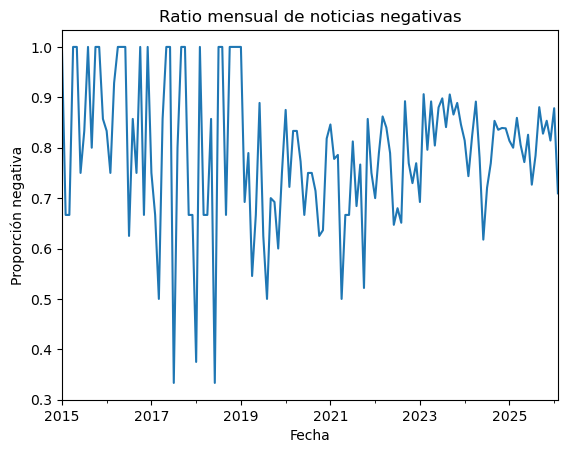

In [40]:
#Proporción mensual de negatividad
sent_month['Ratio_Neg'] = (
    sent_month['Negativa'] /
    (sent_month['Negativa'] + sent_month['Positiva'])
)
plt.figure()
sent_month['Ratio_Neg'].plot()
plt.title('Ratio mensual de noticias negativas')
plt.xlabel('Fecha')
plt.ylabel('Proporción negativa')
plt.show()



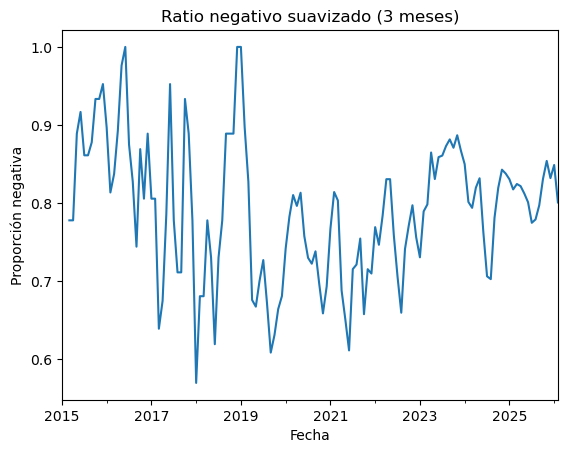

In [42]:
sent_month['Diferencial'] = (
    sent_month['Negativa'] - sent_month['Positiva']
)
sent_month['Ratio_Neg_3M'] = sent_month['Ratio_Neg'].rolling(3).mean()

plt.figure()
sent_month['Ratio_Neg_3M'].plot()
plt.title('Ratio negativo suavizado (3 meses)')
plt.xlabel('Fecha')
plt.ylabel('Proporción negativa')
plt.show()


In [52]:
df['Fuente'].value_counts()
df['Fuente'].value_counts(normalize=True)
noticias_por_fuente = df['Fuente'].value_counts()
noticias_por_fuente


Fuente
Infobae                636
Energía Estratégica    303
LaRepublica.co         295
ELTIEMPO.COM           280
Portafolio.co          251
                      ... 
pv magazine España       1
procuraduria.gov.co      1
ADN Celam                1
AFP Factual              1
Teletrece                0
Name: count, Length: 587, dtype: int64

## Análisis por fuentes ##

In [47]:
tabla_fuente = pd.crosstab(
    df['Fuente'],
    df['Tipo_noticia'],
    normalize='index'
)

tabla_fuente


Tipo_noticia,Negativa,Positiva
Fuente,,
- CIPER Chile,0.666667,0.333333
20Minutos,1.000000,0.000000
360 Radio,0.833333,0.166667
724 | noticias,1.000000,0.000000
:.Periodicovirtual.com.:,0.000000,1.000000
...,...,...
www.gub.uy,1.000000,0.000000
www.laprensa.hn,1.000000,0.000000
www.metrolibre.com,1.000000,0.000000


In [55]:
noticias_por_fuente = df['Fuente'].value_counts()

tabla_frecuencia = (
    noticias_por_fuente
    .value_counts()
    .rename_axis('Numero_Noticias')
    .reset_index(name='Cantidad_Fuentes')
    .sort_values('Numero_Noticias')
)
tabla_frecuencia


,Numero_Noticias,Cantidad_Fuentes
50,0,1
0,1,286
1,2,91
2,3,56
4,4,23
3,5,25
5,6,17
10,7,5
7,8,7
9,9,6


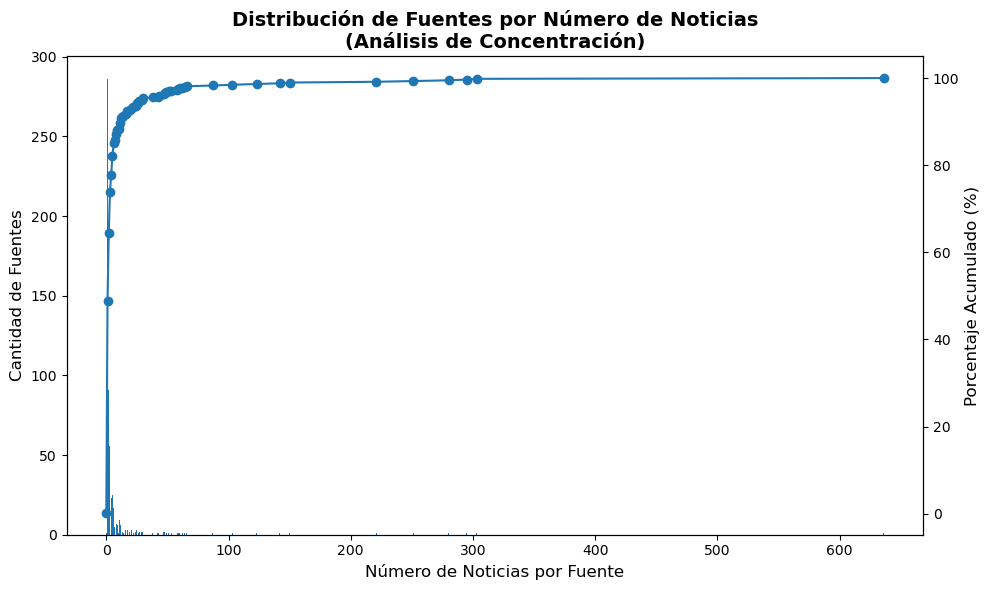

In [56]:
noticias_por_fuente = df['Fuente'].value_counts()

tabla_frecuencia = (
    noticias_por_fuente
    .value_counts()
    .rename_axis('Numero_Noticias')
    .reset_index(name='Cantidad_Fuentes')
    .sort_values('Numero_Noticias')
)

# Calcular acumulado
tabla_frecuencia['Acumulado'] = (
    tabla_frecuencia['Cantidad_Fuentes'].cumsum()
)

tabla_frecuencia['Acumulado_%'] = (
    tabla_frecuencia['Acumulado'] /
    tabla_frecuencia['Cantidad_Fuentes'].sum()
) * 100
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

# Barras
ax1.bar(
    tabla_frecuencia['Numero_Noticias'],
    tabla_frecuencia['Cantidad_Fuentes']
)

ax1.set_xlabel('Número de Noticias por Fuente', fontsize=12)
ax1.set_ylabel('Cantidad de Fuentes', fontsize=12)

# Segundo eje para acumulado
ax2 = ax1.twinx()
ax2.plot(
    tabla_frecuencia['Numero_Noticias'],
    tabla_frecuencia['Acumulado_%'],
    marker='o'
)

ax2.set_ylabel('Porcentaje Acumulado (%)', fontsize=12)

plt.title('Distribución de Fuentes por Número de Noticias\n(Análisis de Concentración)',
          fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


# MODELOS Y MINERÍA DE DATOS #

In [57]:
# Variable Objetivo
df['y'] = df['Tipo_noticia'].map({'Negativa': 1, 'Positiva': 0})


,Query,Titulo,Fuente,Fecha,Hora,Año,Mes,Titulo_norm,Tipo_noticia,Dia_Semana,Longitud_Titular,Conteo_Palabras,YearMonth,y
3885,energía Colombia,"""Hidrosogamoso nos aleja de un racionamiento d...",Vanguardia,2015-01-15,00:00:00,2015,1,hidrosogamoso nos aleja de un racionamiento de...,Negativa,Thursday,75,12,2015-01,1
3886,energía Colombia,Hidroeléctrica El Quimbo al fin generará desde...,El Colombiano,2015-01-18,00:00:00,2015,1,hidroelectrica el quimbo al fin generara desde...,Negativa,Sunday,68,11,2015-01,1
1933,consumo energía sector industrial Colombia,CFE licitará 12 proyectos de infraestructura e...,obras.expansion.mx,2015-01-28,08:00:00,2015,1,cfe licitara 12 proyectos de infraestructura e...,Negativa,Wednesday,54,7,2015-01,1
3887,energía Colombia,Energía renovable latinoamericana aguanta bajo...,IPS Agencia de Noticias,2015-02-18,00:00:00,2015,2,energia renovable latinoamericana aguanta bajo...,Positiva,Wednesday,66,7,2015-02,0
3888,energía Colombia,Tres nuevas hidroeléctricas generarán 517 mega...,LaRepublica.co,2015-02-20,00:00:00,2015,2,tres nuevas hidroelectricas generaran 517 mega...,Negativa,Friday,79,11,2015-02,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,precio escasez CREG Colombia actualización,Urrá anunció que se acogerá a medidas de preci...,LaRepublica.co,2026-02-13,00:48:46,2026,2,urra anuncio que se acogera a medidas de preci...,Negativa,Friday,85,16,2026-02,1
3690,precio contratos largo plazo energía Colombia,Trump ordena al Pentágono impulsar el uso de c...,Infobae,2026-02-13,09:45:00,2026,2,trump ordena al pentagono impulsar el uso de c...,Negativa,Friday,113,20,2026-02,1
301,precio escasez CREG Colombia actualización,Urrá se acoge a medida de precios de escasez p...,larazon.co,2026-02-13,13:03:18,2026,2,urra se acoge a medida de precios de escasez p...,Negativa,Friday,91,15,2026-02,1
300,precio escasez CREG Colombia actualización,Urrá anuncia que bajarán los precios de la ene...,Infobae,2026-02-13,14:15:00,2026,2,urra anuncia que bajaran los precios de la ene...,Positiva,Friday,97,19,2026-02,0
